# Garbage Classification Tiny CNN — All TFLite Quantization Options

This notebook is the **Assignment 4 baseline**:
- Download or load a dataset
- Train a tiny grayscale CNN classifier (NPU-friendly ops)
- Export **all five TFLite quantization variants**:
  1. Float32 (no quantization)
  2. Dynamic-range quantization
  3. Float16 quantization
  4. Full int8, float I/O (recommended for Nicla Vision)
  5. Full int8, strict int8 I/O
- Sanity-check every exported model on desktop with `tf.lite.Interpreter`


In [19]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset

Two options:  Using Option B

### Option A: local folder dataset (recommended for your own custom objects)
```
data/
  train/
    mug/
    keys/
    remote/
  val/
    mug/
    keys/
    remote/
```

### Option B: KaggleHub download (good for a quick public dataset)
Example:
```
import kagglehub
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
```

For Option B we do a stratified train/val split on the fly.


In [20]:
USE_KAGGLEHUB = True
KAGGLE_DATASET = "asdasdasasdas/garbage-classification"
FORCE_CLASS_ROOT = None  # set to a path string if auto-detection picks the wrong folder

DATA_DIR = Path('data')
IMG_SZ = 64   # 96 exceeded Nicla Vision tensor arena; 64x64x16 = 65 KB fits in STM32H747 framebuffer
BATCH = 64
VAL_FRAC = 0.2

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


def _has_images(p: Path) -> bool:
    for f in p.iterdir():
        if f.is_file() and f.suffix.lower() in IMG_EXTS:
            return True
    return False


def find_class_root(root: Path, max_depth: int = 6) -> Path:
    """Find a directory whose immediate subfolders look like class folders."""
    root = root.resolve()
    best = None
    best_score = (-1, -1)

    def depth(p: Path) -> int:
        try:
            return len(p.relative_to(root).parts)
        except Exception:
            return 999

    dirs = [root]
    for p in root.rglob('*'):
        if p.is_dir() and depth(p) <= max_depth:
            dirs.append(p)

    for d in dirs:
        subdirs = [s for s in d.iterdir() if s.is_dir()]
        if len(subdirs) < 2:
            continue
        class_dirs = [s for s in subdirs if _has_images(s)]
        if len(class_dirs) < 2:
            continue

        img_count = 0
        for c in class_dirs:
            img_count += sum(1 for f in c.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXTS)
        score = (len(class_dirs), img_count)
        if score > best_score:
            best_score = score
            best = d

    if best is None:
        raise RuntimeError(f"Could not find class folders under: {root}")
    return best


def index_from_class_root(class_root: Path):
    class_dirs = [d for d in class_root.iterdir() if d.is_dir() and _has_images(d)]
    class_names = sorted([d.name for d in class_dirs])
    name_to_id = {n: i for i, n in enumerate(class_names)}

    items = []
    for cname in class_names:
        cdir = class_root / cname
        for p in sorted(cdir.iterdir()):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                items.append((str(p), name_to_id[cname]))
    return items, class_names


def split_items(items, val_frac=0.2):
    from collections import defaultdict

    by_cls = defaultdict(list)
    for p, y in items:
        by_cls[int(y)].append(p)

    train, val = [], []
    rng = np.random.default_rng(0)
    for y, paths in by_cls.items():
        paths = list(paths)
        rng.shuffle(paths)
        n_val = int(len(paths) * val_frac)
        val_paths = paths[:n_val]
        train_paths = paths[n_val:]
        train.extend([(p, y) for p in train_paths])
        val.extend([(p, y) for p in val_paths])

    rng.shuffle(train)
    rng.shuffle(val)
    return train, val


def load_image_label(path, y):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize_with_pad(img, IMG_SZ, IMG_SZ)
    img = tf.cast(tf.clip_by_value(img, 0, 255), tf.float32) / 255.0
    return img, tf.cast(y, tf.int32)


def ds_from_items(items, shuffle=False):
    paths = [p for p, _ in items]
    labels = [int(y) for _, y in items]
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(4096, len(paths)), seed=0)
    ds = ds.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds


train_dir = DATA_DIR / 'train'
val_dir = DATA_DIR / 'val'

if (not USE_KAGGLEHUB) and train_dir.exists() and val_dir.exists():
    print('Using folder dataset:', train_dir, val_dir)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        str(train_dir),
        labels='inferred',
        label_mode='int',
        color_mode='grayscale',
        image_size=(IMG_SZ, IMG_SZ),
        batch_size=BATCH,
        shuffle=True,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        str(val_dir),
        labels='inferred',
        label_mode='int',
        color_mode='grayscale',
        image_size=(IMG_SZ, IMG_SZ),
        batch_size=BATCH,
        shuffle=False,
    )
    class_names = train_ds.class_names
    train_ds = train_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
else:
    import kagglehub
    path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    print('KaggleHub dataset path:', path)

    class_root = Path(FORCE_CLASS_ROOT) if FORCE_CLASS_ROOT else find_class_root(path)
    print('Class root:', class_root)

    items, class_names = index_from_class_root(class_root)
    train_items, val_items = split_items(items, val_frac=VAL_FRAC)
    print('Train images:', len(train_items), 'Val images:', len(val_items))
    print('Classes:', class_names)

    train_ds = ds_from_items(train_items, shuffle=True)
    val_ds = ds_from_items(val_items, shuffle=False)


NUM_CLASSES = len(class_names)
print('NUM_CLASSES:', NUM_CLASSES)


Using Colab cache for faster access to the 'garbage-classification' dataset.
KaggleHub dataset path: /kaggle/input/garbage-classification
Class root: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
Train images: 2024 Val images: 503
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES: 6


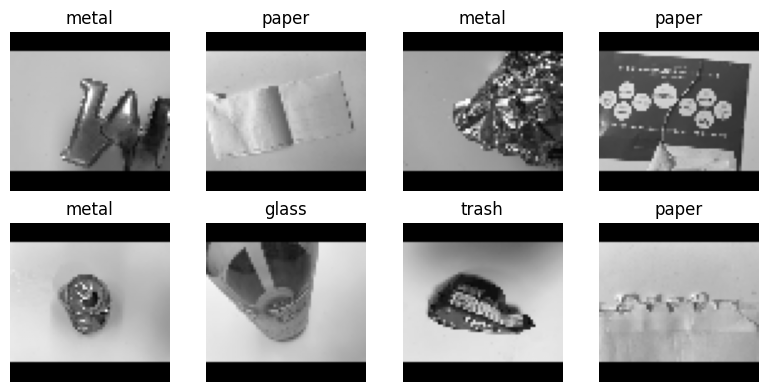

In [21]:
# Visualize a small batch
x, y = next(iter(train_ds))
plt.figure(figsize=(8, 4))
for i in range(min(8, x.shape[0])):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x[i,:,:,0], cmap='gray', vmin=0, vmax=1)
    plt.title(class_names[int(y[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 2) Tiny, NPU-friendly CNN

Design constraints for edge/NPU:
- Prefer `Conv2D`, `DepthwiseConv2D`, `Add`, `ReLU`, `GlobalAveragePooling`
- Avoid big fully-connected layers
- Keep channels modest


In [22]:
from tensorflow.keras import layers, models

def build_tiny_ds_cnn(input_shape=(64, 64, 1), num_classes=3):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(24, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.DepthwiseConv2D(3, padding='same', activation='relu')(x)
    x = layers.Conv2D(32, 1, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out, name='tiny_ds_cnn')


model = build_tiny_ds_cnn(input_shape=(IMG_SZ, IMG_SZ, 1), num_classes=NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()


Model: "tiny_ds_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_4              │ (None, 32, 32, 16)     │           160 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 24)     │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_5              │ (None, 16, 16, 24)     │           240 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 32)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,966 (7.68 KB)

 Trainable params: 1,966 (7.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
32/32 - 12s - 360ms/step - accuracy: 0.2243 - loss: 1.7779 - val_accuracy: 0.2346 - val_loss: 1.7582
Epoch 2/200
32/32 - 2s - 76ms/step - accuracy: 0.2352 - loss: 1.7429 - val_accuracy: 0.2346 - val_loss: 1.7258
Epoch 3/200
32/32 - 2s - 78ms/step - accuracy: 0.2352 - loss: 1.7244 - val_accuracy: 0.2346 - val_loss: 1.7191
Epoch 4/200
32/32 - 2s - 77ms/step - accuracy: 0.2352 - loss: 1.7228 - val_accuracy: 0.2346 - val_loss: 1.7186
Epoch 5/200
32/32 - 2s - 63ms/step - accuracy: 0.2352 - loss: 1.7205 - val_accuracy: 0.2346 - val_loss: 1.7175
Epoch 6/200
32/32 - 2s - 65ms/step - accuracy: 0.2352 - loss: 1.7203 - val_accuracy: 0.2346 - val_loss: 1.7163
Epoch 7/200
32/32 - 3s - 90ms/step - accuracy: 0.2352 - loss: 1.7192 - val_accuracy: 0.2346 - val_loss: 1.7145
Epoch 8/200
32/32 - 2s - 62ms/step - accuracy: 0.2352 - loss: 1.7161 - val_accuracy: 0.2346 - val_loss: 1.7124
Epoch 9/200
32/32 - 2s - 61ms/step - accuracy: 0.2352 - loss: 1.7137 - val_accuracy: 0.2346 - val_loss: 1.7069

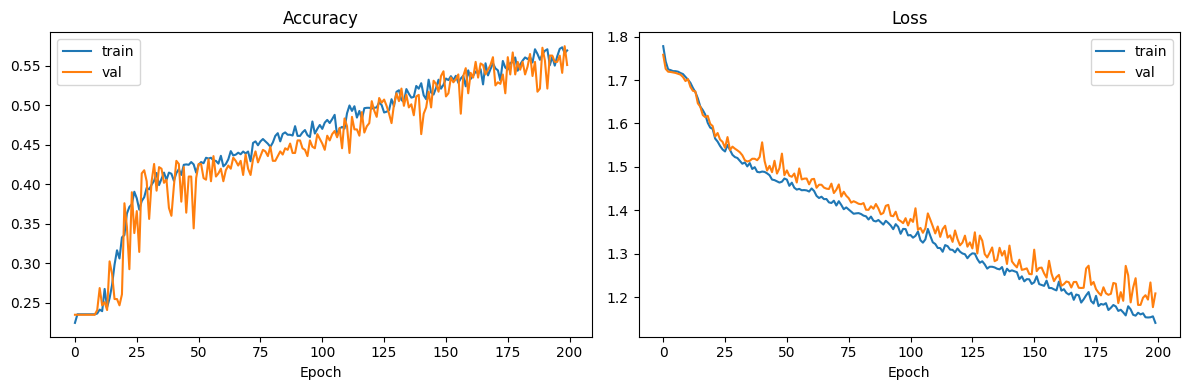

In [23]:
  early_stop = tf.keras.callbacks.EarlyStopping(
      monitor='val_loss',
      patience=10,
      restore_best_weights=True,
  )

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=200,
      callbacks=[early_stop],
      verbose=2,
  )

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

  ax1.plot(history.history['accuracy'], label='train')
  ax1.plot(history.history['val_accuracy'], label='val')
  ax1.set_title('Accuracy')
  ax1.set_xlabel('Epoch')
  ax1.legend()

  ax2.plot(history.history['loss'], label='train')
  ax2.plot(history.history['val_loss'], label='val')
  ax2.set_title('Loss')
  ax2.set_xlabel('Epoch')
  ax2.legend()

  plt.tight_layout()
  plt.show()



## 3) Export — all TFLite quantization variants

| # | Name | File | I/O type | Rep. dataset? | Notes |
|---|------|------|----------|---------------|-------|
| 1 | Float32 | `custom_objects_float32.tflite` | float32 | No | No quantization; largest file |
| 2 | Dynamic-range | `custom_objects_dynamic_range.tflite` | float32 | No | Weights→int8, activations inferred at runtime |
| 3 | Float16 | `custom_objects_float16.tflite` | float32 | No | Weights→float16; good for GPU delegates |
| 4 | Full int8, float I/O | `custom_objects_int8_float_io.tflite` | **float32** | Yes | Recommended for Nicla Vision; internal ops int8 |
| 5 | Full int8, int8 I/O | `custom_objects_int8.tflite` | **int8** | Yes | Strictest; may fail if boundary ops lack int8 kernels |

**Why does plain int8 (option 5) sometimes fail on Nicla Vision?**
Setting `inference_input_type=tf.int8` / `inference_output_type=tf.int8` requires *every* boundary op to
have an int8 kernel. The float I/O variant (option 4) omits those settings, so TFLite inserts trivial
float↔int8 casts at the boundary — universally supported, nearly the same model size.


In [24]:
import os
import numpy as np
import tensorflow as tf

def representative_dataset(ds, num_batches=50):
    for x, _ in ds.take(num_batches):
        for i in range(x.shape[0]):
            yield [tf.expand_dims(x[i], 0)]


os.makedirs('models', exist_ok=True)

# ── Helper ────────────────────────────────────────────────────────────────────
def export(name, setup_fn):
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    setup_fn(conv)
    data = conv.convert()
    path = os.path.join('models', name)
    with open(path, 'wb') as f:
        f.write(data)
    print(f'  {path}  ({os.path.getsize(path):,} bytes)')
    return path


# 1) Float32 — no quantization
print('1) float32')
def setup_float32(c):
    pass
path_float32 = export('custom_objects_float32.tflite', setup_float32)

# 2) Dynamic-range
print('2) dynamic-range')
def setup_dynamic(c):
    c.optimizations = [tf.lite.Optimize.DEFAULT]
path_dynamic = export('custom_objects_dynamic_range.tflite', setup_dynamic)

# 3) Float16
print('3) float16')
def setup_fp16(c):
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.target_spec.supported_types = [tf.float16]
path_fp16 = export('custom_objects_float16.tflite', setup_fp16)

# 4) Full int8, float I/O  ← recommended for Nicla Vision
print('4) full int8, float I/O')
def setup_int8_float_io(c):
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.representative_dataset = lambda: representative_dataset(train_ds)
    c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # Intentionally omit inference_input_type / inference_output_type
path_int8_fio = export('custom_objects_int8_float_io.tflite', setup_int8_float_io)

# 5) Full int8, strict int8 I/O
print('5) full int8, strict int8 I/O')
def setup_int8_strict(c):
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.representative_dataset = lambda: representative_dataset(train_ds)
    c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    c.inference_input_type  = tf.int8
    c.inference_output_type = tf.int8
try:
    path_int8 = export('custom_objects_int8.tflite', setup_int8_strict)
except Exception as e:
    path_int8 = None
    print(f'  FAILED: {e}')
    print('  → This is expected on some op sets; use option 4 (float I/O) instead.')

# Labels
labels_path = os.path.join('models', 'custom_objects_labels.txt')
with open(labels_path, 'w', encoding='utf-8') as f:
    for n in class_names:
        f.write(n + '\n')
print('Labels:', labels_path)
print('Classes:', class_names)


1) float32
Saved artifact at '/tmp/tmpbg_pxvxn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138220570170128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570172048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570167824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570173008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570173200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570168592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570175120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570176272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570174736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570172240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  models/custom_objects_int8_float_io.tflite  (10,808 bytes)
5) full int8, strict int8 I/O
Saved artifact at '/tmp/tmpcwk4pk4x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138220570170128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570172048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570167824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570173008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570173200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570168592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570175120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570176272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138220570174736: TensorSpec(shape=(), dtype=tf.resource, name=

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  models/custom_objects_int8.tflite  (10,448 bytes)
Labels: models/custom_objects_labels.txt
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4) Sanity-check all exported models

Run every `.tflite` through `tf.lite.Interpreter` and confirm it produces a sensible prediction.
For int8 I/O models the input must be manually quantized; for float32 I/O models feed directly.


In [25]:
import numpy as np
import tensorflow as tf
import os

xb, yb = next(iter(val_ds))
x0_f32 = xb[0:1].numpy()   # (1, IMG_SZ, IMG_SZ, 1), float32
y0 = int(yb[0].numpy())

def run_tflite(tflite_path, x_f32):
    """Run one sample through a .tflite and return predicted class index."""
    interp = tf.lite.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]

    if inp['dtype'] == np.int8:
        scale, zp = inp['quantization']
        x_in = np.round(x_f32 / scale + zp).astype(np.int8)
    else:
        x_in = x_f32.astype(np.float32)

    interp.set_tensor(inp['index'], x_in)
    interp.invoke()
    raw = interp.get_tensor(out['index'])[0]

    if out['dtype'] == np.int8:
        oscale, ozp = out['quantization']
        probs = (raw.astype(np.float32) - ozp) * oscale
    else:
        probs = raw.astype(np.float32)

    return int(np.argmax(probs)), float(np.max(probs)), inp['dtype'], out['dtype']


models_to_check = [
    ('1 float32',           'models/custom_objects_float32.tflite'),
    ('2 dynamic-range',     'models/custom_objects_dynamic_range.tflite'),
    ('3 float16',           'models/custom_objects_float16.tflite'),
    ('4 int8 float I/O',    'models/custom_objects_int8_float_io.tflite'),
    ('5 int8 strict I/O',   'models/custom_objects_int8.tflite'),
]

print(f'Ground truth: {class_names[y0]}\n')
print(f'{"Model":<22} {"In dtype":<12} {"Out dtype":<12} {"Pred":<12} {"Conf"}')
print('-' * 70)
for label, path in models_to_check:
    if not os.path.exists(path):
        print(f'{label:<22}  SKIPPED (not produced)')
        continue
    pred, conf, in_dt, out_dt = run_tflite(path, x0_f32)
    match = '✓' if pred == y0 else '✗'
    print(f'{label:<22} {str(in_dt.__name__):<12} {str(out_dt.__name__):<12} '
          f'{class_names[pred]:<12} {conf:.1%} {match}')


Ground truth: cardboard

Model                  In dtype     Out dtype    Pred         Conf
----------------------------------------------------------------------
1 float32              float32      float32      cardboard    57.6% ✓
2 dynamic-range        float32      float32      cardboard    57.6% ✓
3 float16              float32      float32      cardboard    57.6% ✓
4 int8 float I/O       float32      float32      cardboard    54.7% ✓
5 int8 strict I/O      int8         int8         cardboard    54.7% ✓


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
